<img src="https://medellin.unal.edu.co/eventos/panam2018/images/imagenes/organizan_2.png" width="40%">

# Procesamiento Digital de Imágenes

## Departamento de ingeniería eléctrica, electrónica y computación
## Sede Manizales

### Profesores Diego Pérez

In [ ]:
%%capture
# Instalar y actualizar bibliotecas necesarias
!pip install gdown
!pip install roboflow
!pip install ipywidgets
!pip install ultralytics

In [3]:
# Importar bibliotecas a usar y deshabilitar WanDB

import os
import yaml
import gdown
import wandb
import shutil
import requests
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image

os.environ['WANDB_DISABLED'] = 'true'
import wandb

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace("sergios-workspace-ajtlg").project("v9_ucrania_deforestacion")
version = project.version(1)
dataset = version.download("yolov8")

In [ ]:
# Entrenar YOLOv9 para detección de aisladores

# Carga de modelo preentrenado
model = YOLO('yolov8s-seg.pt')

# Entrenar el modelo
results = model.train(data='/content/V9_Ucrania_Deforestación-1/data.yaml', epochs=300, imgsz=640, device=0)


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/V9_Ucrania_Deforestación-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [4]:
# Validar el modelo entrenado

# Carga de modelo entrenado
model = YOLO('/content/runs/segment/train3/weights/best.pt')

# Realizar validación
validation_results = model.val(data='/content/V9_Ucrania_Deforestación-1/data.yaml',
                               imgsz=640,
                               batch=16,
                               conf=0.5,
                               iou=0.6,
                               device='0')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1850.4±747.9 MB/s, size: 45.3 KB)
val: Scanning /content/V9_Ucrania_Deforestación-1/valid/labels.cache... 19 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 2.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.2s
                   all         19        664       0.75     0.0271      0.387      0.247      0.792     0.0286      0.409       0.25
Speed: 10.2ms preprocess, 29.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/segment/val3



image 1/1 /content/V9_Ucrania_Deforestación-1/test/images/img4_15_12_png.rf.e2f2366b47479183b4dc5ace29f8eba7.jpg: 640x640 19 deforestations, 27.3ms
Speed: 5.7ms preprocess, 27.3ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict


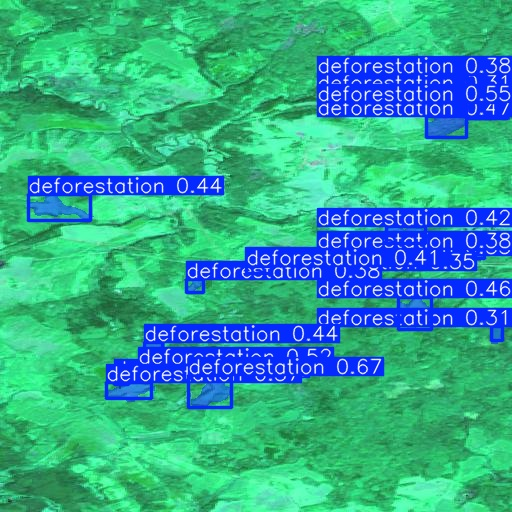

In [20]:
# Directorio de la imagen
imagen_dir = '/content/V9_Ucrania_Deforestación-1/test/images/img4_15_12_png.rf.e2f2366b47479183b4dc5ace29f8eba7.jpg'
# Realizar una inferencia
model.predict(imagen_dir, save=True, imgsz=640, conf=0.3, show_boxes=True, show_labels=True)
# Mostrar imagen sobre la cual se hizo inferencia
Image(filename="/content/runs/segment/predict/"+imagen_dir.rsplit('/', 1)[-1])

In [ ]:
# Realizar validación
validation_results = model.val(data='/content/Car-1/data.yaml',
                               imgsz=640,
                               batch=16,
                               conf=0.5,
                               iou=0.6,
                               device='0')

In [ ]:
project.version(dataset.version).deploy(model_type="yolov10", model_path=f"/content/runs/detect/train")